# Bank Customer Churn Prediction
**MSE 446 — Group 3**

---

## Section 1 — Exploratory Data Analysis

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'data/raw/Customer-Churn-Records.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')

Shape: (10000, 18)


### 1.1 Dataset Overview

In [22]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [24]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000



The dataset contains 10,000 observations and 14 features. It includes a mix of numerical variables (e.g., Age, Balance, CreditScore) and categorical variables (e.g., Geography, Gender, Card Type). 

The target variable is `Exited`, which indicates whether a customer has churned (1) or been retained (0).

### 1.2 Missing Values & Duplicates

In [25]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None')

dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')

Missing values per column:
None

Duplicate rows: 0



No missing values or duplicate records were detected in the dataset. This indicates that the data is already clean and does not require imputation or deduplication prior to modeling.

### 1.3 Class Imbalance

Churn distribution:
  Retained (0): 7,962  (79.6%)
  Churned (1): 2,038  (20.4%)


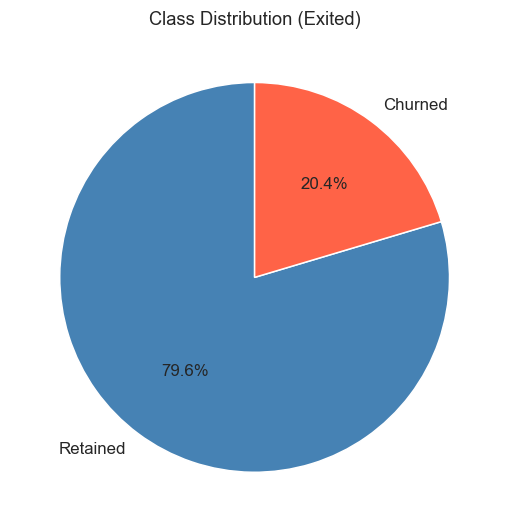

In [26]:
counts = df['Exited'].value_counts()
pcts   = df['Exited'].value_counts(normalize=True) * 100

print('Churn distribution:')
for label, cnt, pct in zip(['Retained (0)', 'Churned (1)'], counts, pcts):
    print(f'  {label}: {cnt:,}  ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['steelblue', 'tomato']
wedges, texts, autotexts = ax.pie(counts, labels=['Retained', 'Churned'], colors=colors, 
                                    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Class Distribution (Exited)', fontsize=12)
plt.tight_layout()
plt.show()


The dataset exhibits a moderate class imbalance, with approximately 20% of customers having churned and 80% retained.

Due to this imbalance, accuracy is not an appropriate standalone evaluation metric, as a model can achieve high accuracy by simply predicting the majority class.

Instead, recall will be prioritized to ensure that churned customers are correctly identified, minimizing false negatives. In addition, the F1-score will be used to balance recall and precision, ensuring that improvements in recall do not come at the cost of excessive false positives.

This aligns with the objective of identifying at-risk customers for retention strategies, where failing to detect a churner is more costly than incorrectly flagging a non-churner.

### 1.4 Key Feature vs Churn Visualizations

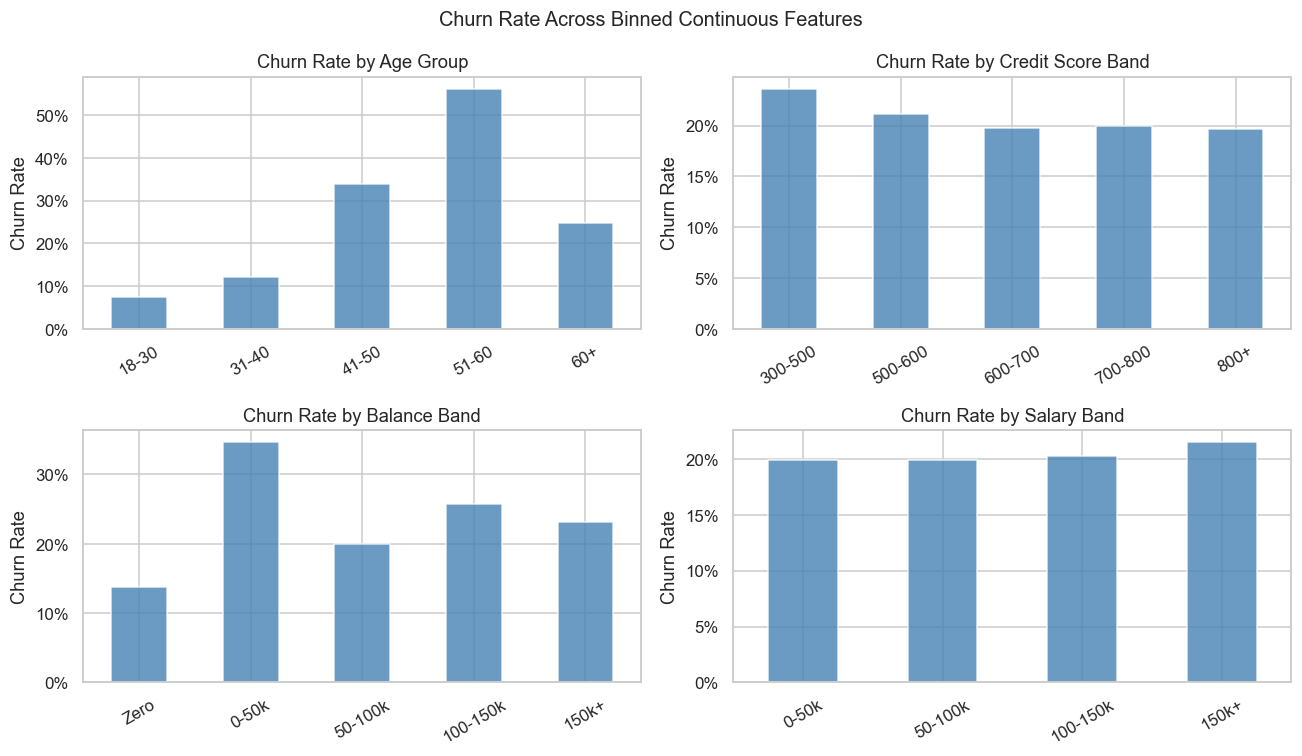

In [27]:
# Bin continuous features, then plot churn rate per bin 
age_churn    = df.groupby(pd.cut(df["Age"],             [18,30,40,50,60,92],        labels=["18-30","31-40","41-50","51-60","60+"]),    observed=True)["Exited"].mean()
credit_churn = df.groupby(pd.cut(df["CreditScore"],     [300,500,600,700,800,851],   labels=["300-500","500-600","600-700","700-800","800+"]), observed=True)["Exited"].mean()
balance_churn= df.groupby(pd.cut(df["Balance"],         [-1,0,50000,100000,150000,300000], labels=["Zero","0-50k","50-100k","100-150k","150k+"]),   observed=True)["Exited"].mean()
salary_churn = df.groupby(pd.cut(df["EstimatedSalary"], [0,50000,100000,150000,200001],    labels=["0-50k","50-100k","100-150k","150k+"]),             observed=True)["Exited"].mean()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 7))

age_churn.plot(kind="bar",    ax=ax1, color="steelblue", alpha=0.8, edgecolor="white")
credit_churn.plot(kind="bar", ax=ax2, color="steelblue", alpha=0.8, edgecolor="white")
balance_churn.plot(kind="bar",ax=ax3, color="steelblue", alpha=0.8, edgecolor="white")
salary_churn.plot(kind="bar", ax=ax4, color="steelblue", alpha=0.8, edgecolor="white")

ax1.set_title("Churn Rate by Age Group")
ax2.set_title("Churn Rate by Credit Score Band")
ax3.set_title("Churn Rate by Balance Band")
ax4.set_title("Churn Rate by Salary Band")

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel("")
    ax.set_ylabel("Churn Rate")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Churn Rate Across Binned Continuous Features", fontsize=13)
plt.tight_layout()
plt.show()

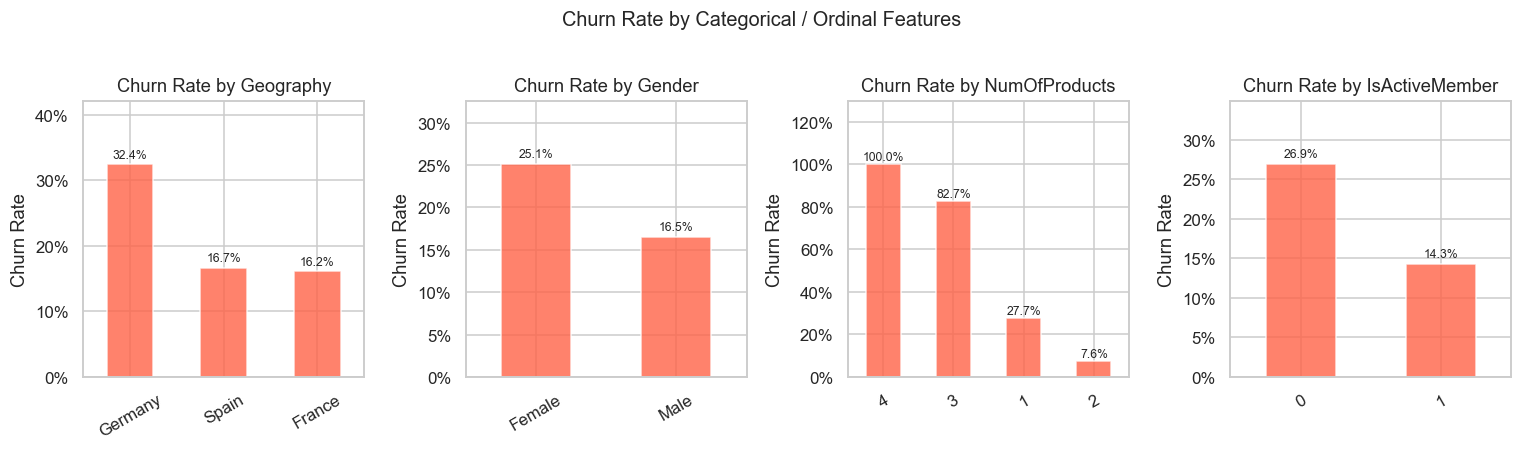

In [28]:
# Categorical / ordinal features: Geography, Gender, NumOfProducts, IsActiveMember
cat_features = ['Geography', 'Gender', 'NumOfProducts', 'IsActiveMember']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, cat_features):
    churn_rate = df.groupby(col)['Exited'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='tomato', alpha=0.8, edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.set_ylim(0, churn_rate.max() * 1.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(ax.patches, churn_rate):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Churn Rate by Categorical / Ordinal Features', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Several key patterns emerge from the feature analysis:

- Churn rate increases with age, suggesting that older customers are more likely to leave the bank  
- Customers with non-zero balances tend to churn more frequently than those with zero balances  
- Inactive members exhibit significantly higher churn rates compared to active customers  
- Customers with a higher number of products (3–4) show elevated churn risk  
- Certain geographic segments (e.g., Germany) display notably higher churn rates  

These relationships indicate that both behavioral and demographic factors contribute to customer churn.

### 1.5 Correlation Heatmap

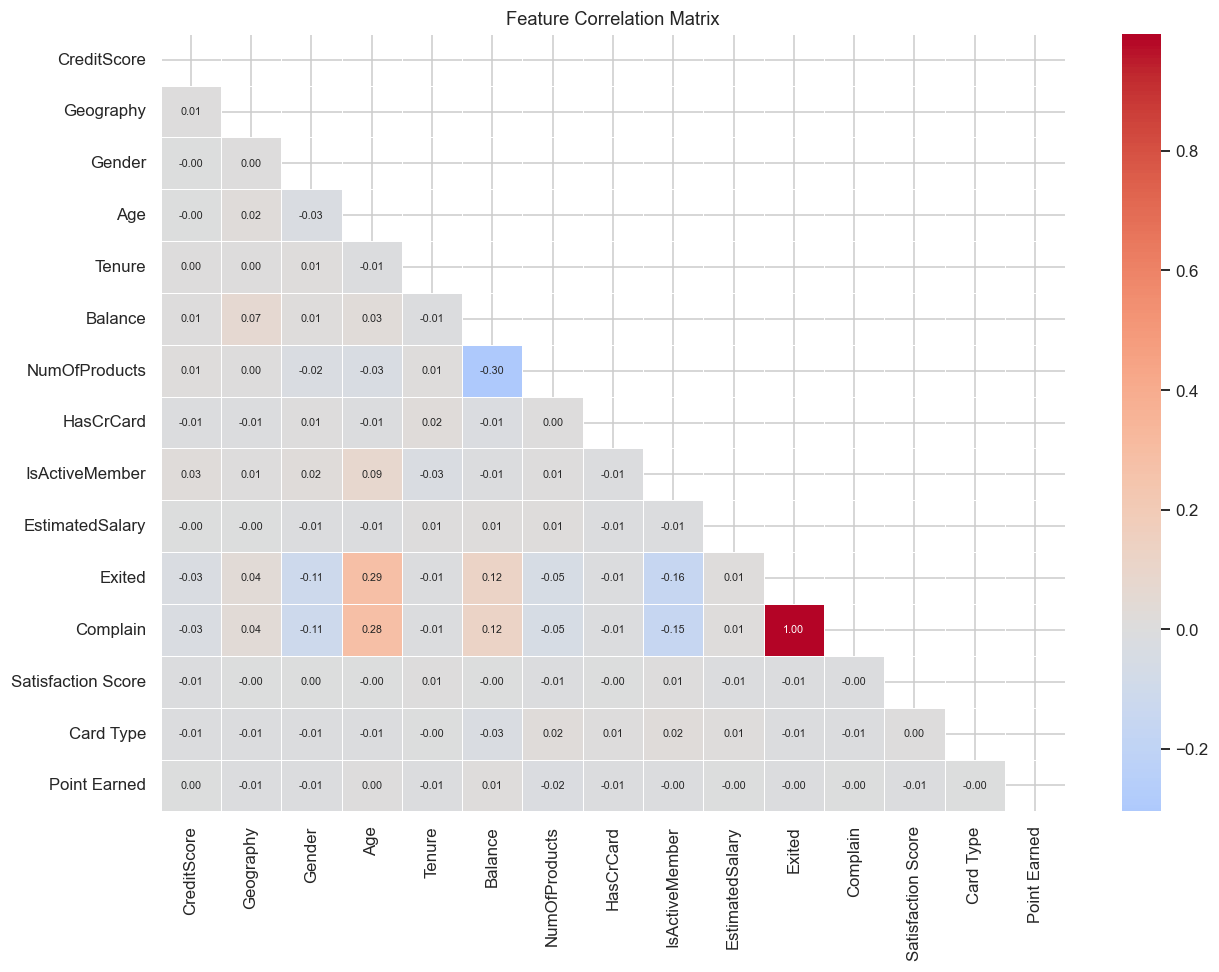

In [29]:
# Encode categoricals minimally for correlation purposes only
df_corr = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
df_corr["Geography"] = df_corr["Geography"].astype("category").cat.codes
df_corr["Gender"]    = df_corr["Gender"].astype("category").cat.codes
df_corr["Card Type"] = df_corr["Card Type"].astype("category").cat.codes

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.show()

The correlation analysis reveals the following:

- **Complain ↔ Exited ≈ 1.0** — this near-perfect correlation indicates that `Complain` is a post-event variable and acts as a proxy for churn. Including it would introduce data leakage, so it must be removed before modeling  
- **Age** shows the strongest legitimate positive correlation with churn among continuous variables  
- **IsActiveMember** has a meaningful negative correlation with churn, indicating that active users are less likely to leave  
- Most other features exhibit weak correlations with each other, which is beneficial for tree-based models as it reduces redundancy and multicollinearity  

Overall, the feature space is well-suited for tree-based methods.

### 1.6 Summary of EDA Insights

| Observation | Detail |
|---|---|
| **Class imbalance** | ~20% churn vs ~80% retained — moderate imbalance; recall is the primary metric |
| **Age** | Churned customers skew older (~45) vs retained (~35); strongest continuous predictor |
| **Balance** | Bimodal in retained (many zero-balance accounts); churned customers tend to carry positive balances |
| **NumOfProducts** | Customers with 3–4 products churn at very high rates |
| **Geography** | Germany churn rate (~32%) roughly double France/Spain (~16%) |
| **IsActiveMember** | Inactive members churn at ~27% vs ~14% for active members |
| **Complain** | Near-perfect correlation with `Exited` — **data leakage**, must be dropped before modeling |
| **Missing / duplicates** | None found — dataset is clean |
| **Identifiers** | `RowNumber`, `CustomerId`, `Surname` carry no predictive signal — will be dropped |

These insights provide a clear understanding of the dataset and will guide subsequent preprocessing and modeling steps. In particular:

- Class imbalance motivates the use of recall as the primary evaluation metric, supported by F1-score to balance precision and recall  
- Key features such as Age, Balance, and Activity Status are expected to be important predictors  
- The `Complain` variable must be removed to prevent data leakage  
- Minimal preprocessing is required due to the absence of missing values and duplicates  

The next step is to clean the dataset by removing non-informative identifiers and eliminating the leakage variable before preparing the data for modeling.

## Section 2 — Cleaning

In [30]:
df_raw = df.copy()  # preserve original for reference
#  drop identifiers, columns with no predictive singal and data leakage columns
df = df.drop(columns=[ "RowNumber", "CustomerId", "Surname", "Complain"])

print(f"Shape after cleaning: {df.shape}")
print(f"Columns remaining: {df.columns.tolist()}")

Shape after cleaning: (10000, 14)
Columns remaining: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned']


In [31]:
# Confirm no remaining issues
assert df.isnull().sum().sum() == 0, "Unexpected nulls"
assert df.duplicated().sum() == 0,   "Unexpected duplicates"
print("No missing values or duplicates — dataset is clean.")

No missing values or duplicates — dataset is clean.


## Section 3 — Preprocessing

### 3.1 One-Hot Encoding

In [32]:
# OHE for Geography, Gender, Card Type — drop_first=False to avoid implicit assumptions
df = pd.get_dummies(df, columns=["Geography", "Gender", "Card Type"])
print(f"Shape after OHE: {df.shape}")
print(df.dtypes)

Shape after OHE: (10000, 20)
CreditScore             int64
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Satisfaction Score      int64
Point Earned            int64
Geography_France         bool
Geography_Germany        bool
Geography_Spain          bool
Gender_Female            bool
Gender_Male              bool
Card Type_DIAMOND        bool
Card Type_GOLD           bool
Card Type_PLATINUM       bool
Card Type_SILVER         bool
dtype: object


### 3.2 Train / Test Split

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}  |  Test churn rate: {y_test.mean():.3f}")

Train: (8000, 19)  |  Test: (2000, 19)
Train churn rate: 0.204  |  Test churn rate: 0.204


### 3.3 Feature Scaling (Logistic Regression only)

StandardScaler is applied **only for logistic regression**, which is sensitive to feature magnitude. Tree-based models (decision tree, bagging, random forest) split on thresholds and are invariant to monotonic rescaling — scaling neither helps nor hurts them, so we skip it to keep the pipeline simple.

The scaler is **fit on the training set only** and applied to both train and test to prevent data leakage.

In [34]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ["CreditScore", "Age", "Tenure", "Balance",
                   "NumOfProducts", "EstimatedSalary", "Satisfaction Score", "Point Earned"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print("Scaling applied to:", continuous_cols)
print(f"X_train_scaled mean (CreditScore): {X_train_scaled['CreditScore'].mean():.4f}")
print(f"X_train_scaled std  (CreditScore): {X_train_scaled['CreditScore'].std():.4f}")

Scaling applied to: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']
X_train_scaled mean (CreditScore): 0.0000
X_train_scaled std  (CreditScore): 1.0001


## Section 4 — Modeling

helper function

In [35]:
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"{name}")
    print(f"  Recall:  {recall_score(y_true, y_pred):.3f}")
    print(f"  F1:      {f1_score(y_true, y_pred):.3f}")
    print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}")


### 4.1 Logistic Regression (Baseline)

Logistic regression is used as the baseline classifier. Since the dataset is moderately imbalanced and failing to identify a churner is more costly than incorrectly flagging a retained customer, the model is tuned using recall as the primary cross-validation metric. F1-score and ROC-AUC are also reported to provide a more balanced evaluation.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Default logistic regression baseline
lr_model = LogisticRegression(
    class_weight='balanced',  # handle class imbalance
    max_iter=1000,           # ensure convergence
    random_state=42         # reproducibility
)

lr_model.fit(X_train_scaled, y_train)

# Predictions and probabilities

#returns class labels (0 or 1)
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred  = lr_model.predict(X_test_scaled)

#returns probability of the positive class (churn) for each instance in the training/test set
lr_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1] 
lr_test_prob  = lr_model.predict_proba(X_test_scaled)[:, 1]

# Baseline performance
print_metrics("LR Default [Train]", y_train, lr_train_pred, lr_train_prob)
print_metrics("LR Default [Test] ", y_test,  lr_test_pred,  lr_test_prob)




LR Default [Train]
  Recall:  0.690
  F1:      0.492
  ROC-AUC: 0.769
LR Default [Test] 
  Recall:  0.723
  F1:      0.505
  ROC-AUC: 0.780


In [37]:
# Tune regularization strength (C) using 5-fold cross-validation
lr_param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lr_grid = GridSearchCV(
    estimator = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid = lr_param_grid,
    scoring = 'recall',  # prioritize recall for churn prediction
    cv = cv,
    n_jobs = -1 # utilize all CPU cores for faster tuning
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Logistic Regression Parameters")
print(lr_grid.best_params_)
print(f"Best CV Recall: {lr_grid.best_score_:.3f}")

Best Logistic Regression Parameters
{'C': 1}
Best CV Recall: 0.690


#### Tune — search over regularization strength 

LR Tuned  [Train]
  Recall:  0.690
  F1:      0.492
  ROC-AUC: 0.769
LR Tuned  [Test] 
  Recall:  0.723
  F1:      0.505
  ROC-AUC: 0.780

Classification Report (Test Set)
              precision    recall  f1-score   support

    Retained       0.91      0.71      0.80      1592
     Churned       0.39      0.72      0.51       408

    accuracy                           0.71      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.71      0.74      2000



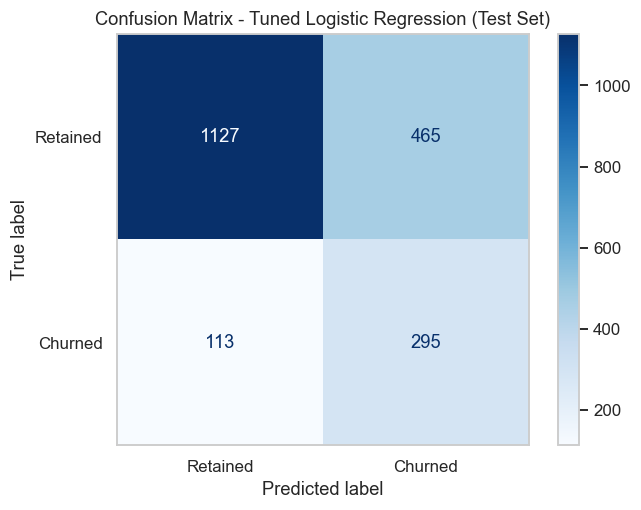

In [38]:
best_lr_model = lr_grid.best_estimator_

best_lr_train_pred = best_lr_model.predict(X_train_scaled)
best_lr_test_pred  = best_lr_model.predict(X_test_scaled)

best_lr_train_prob = best_lr_model.predict_proba(X_train_scaled)[:, 1]
best_lr_test_prob  = best_lr_model.predict_proba(X_test_scaled)[:, 1]

print_metrics("LR Tuned  [Train]", y_train, best_lr_train_pred, best_lr_train_prob)
print_metrics("LR Tuned  [Test] ", y_test,  best_lr_test_pred,  best_lr_test_prob)

print("\nClassification Report (Test Set)")
print(classification_report(
    y_test,
    best_lr_test_pred,
    target_names=["Retained", "Churned"]
))

# Confusion Matrix for tuned logistic regression on test set

cm_lr = confusion_matrix(y_test, best_lr_test_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Retained", "Churned"])
disp_lr.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Tuned Logistic Regression (Test Set)")
plt.grid(False)
plt.tight_layout()
plt.show()


The confusion matrix shows the number of correctly and incorrectly classified customers on the test set. In particular, false negatives represent churners that the model failed to identify, which are the most costly errors in this problem setting.

### 4.2 Decision Tree Classifier

In [39]:
from sklearn.tree import DecisionTreeClassifier

# Fully grown tree — no constraints, unscaled data
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred  = dt_model.predict(X_test)

dt_train_prob = dt_model.predict_proba(X_train)[:, 1]
dt_test_prob  = dt_model.predict_proba(X_test)[:, 1]

print_metrics("Decision Tree Unpruned [Train]", y_train, dt_train_pred, dt_train_prob)
print_metrics("Decision Tree Unpruned [Test] ", y_test,  dt_test_pred,  dt_test_prob)

Decision Tree Unpruned [Train]
  Recall:  1.000
  F1:      1.000
  ROC-AUC: 1.000
Decision Tree Unpruned [Test] 
  Recall:  0.493
  F1:      0.501
  ROC-AUC: 0.686


The fully grown decision tree achieves very high training performance but generalizes poorly to the test set, indicating overfitting. Following the lecture approach, we now apply cost-complexity pruning rather than restricting growth at the outset.

In [40]:
# Step 1: extract the pruning path from the full tree
pruning_path = dt_model.cost_complexity_pruning_path(X_train, y_train)
alpha_candidates = pruning_path.ccp_alphas[:-1]  # drop last — root-only stump

# Subsample if path is long to keep grid manageable
if len(alpha_candidates) > 50:
    idx = np.linspace(0, len(alpha_candidates) - 1, 50, dtype=int)
    alpha_candidates = alpha_candidates[idx]

print(f"Candidate ccp_alpha values: {len(alpha_candidates)}")

# Step 2: use GridSearchCV to pick the alpha that maximizes recall
dt_grid = GridSearchCV(
    estimator  = DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid = {"ccp_alpha": alpha_candidates},
    scoring    = "recall",
    cv         = cv,
    n_jobs     = -1
)
dt_grid.fit(X_train, y_train)

print(f"Best ccp_alpha:  {dt_grid.best_params_['ccp_alpha']:.6f}")
print(f"Best CV Recall:  {dt_grid.best_score_:.3f}")

Candidate ccp_alpha values: 50
Best ccp_alpha:  0.001263
Best CV Recall:  0.767


Cost-complexity pruning generates a sequence of candidate subtrees indexed by , where larger values correspond to more aggressive pruning. Cross-validation is then used to select the value of  that maximizes recall on unseen folds.

Decision Tree Pruned [Train]
  Recall:  0.823
  F1:      0.569
  ROC-AUC: 0.850
Decision Tree Pruned [Test] 
  Recall:  0.821
  F1:      0.562
  ROC-AUC: 0.857

Classification Report (Test Set)
              precision    recall  f1-score   support

    Retained       0.94      0.72      0.81      1592
     Churned       0.43      0.82      0.56       408

    accuracy                           0.74      2000
   macro avg       0.68      0.77      0.69      2000
weighted avg       0.84      0.74      0.76      2000



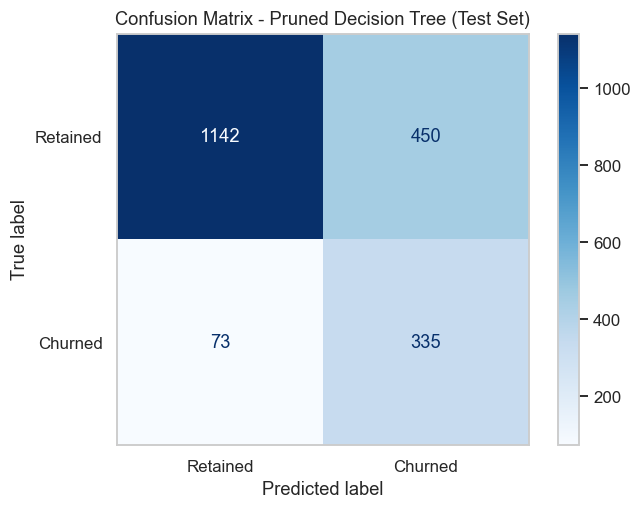

In [41]:
best_dt_model = dt_grid.best_estimator_

best_dt_train_pred = best_dt_model.predict(X_train)
best_dt_test_pred  = best_dt_model.predict(X_test)

best_dt_train_prob = best_dt_model.predict_proba(X_train)[:, 1]
best_dt_test_prob  = best_dt_model.predict_proba(X_test)[:, 1]

print_metrics("Decision Tree Pruned [Train]", y_train, best_dt_train_pred, best_dt_train_prob)
print_metrics("Decision Tree Pruned [Test] ", y_test,  best_dt_test_pred,  best_dt_test_prob)

print()
print("Classification Report (Test Set)")
print(classification_report(y_test, best_dt_test_pred, target_names=["Retained", "Churned"]))

cm_dt = confusion_matrix(y_test, best_dt_test_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Retained", "Churned"])
disp_dt.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Pruned Decision Tree (Test Set)")
plt.grid(False)
plt.tight_layout()
plt.show()

The pruned decision tree reduces overfitting by removing unnecessary branches, resulting in a better bias-variance tradeoff. Although training performance decreases relative to the fully grown tree, the pruned model is expected to generalize more effectively to unseen data.

### 4.3 Ensemble Method Bagging

In [42]:
from sklearn.ensemble import BaggingClassifier

# Use the ccp_alpha selected by CV as the base estimator — avoids bagging fully grown overfit trees
pruned_base = DecisionTreeClassifier(
    class_weight="balanced",
    ccp_alpha=dt_grid.best_params_["ccp_alpha"],
    random_state=42
)

bag_model = BaggingClassifier(estimator=pruned_base, random_state=42, n_jobs=-1)
bag_model.fit(X_train, y_train)

bag_train_pred = bag_model.predict(X_train)
bag_test_pred  = bag_model.predict(X_test)

bag_train_prob = bag_model.predict_proba(X_train)[:, 1]
bag_test_prob  = bag_model.predict_proba(X_test)[:, 1]

print_metrics("Bagging Default [Train]", y_train, bag_train_pred, bag_train_prob)
print_metrics("Bagging Default [Test] ", y_test,  bag_test_pred,  bag_test_prob)

Bagging Default [Train]
  Recall:  0.796
  F1:      0.638
  ROC-AUC: 0.884
Bagging Default [Test] 
  Recall:  0.762
  F1:      0.607
  ROC-AUC: 0.870


Bagging trains multiple trees on bootstrap samples of the training data and averages their predictions. Using the pruned base estimator (with the  selected in 4.2) ensures each tree is already well-regularized. We are aggregating stable trees rather than amplifying the variance of overfit ones.

In [43]:
# Tune the number of estimators for the bagging ensemble
bag_param_grid = {
    "n_estimators": [50, 100, 200, 500]
}

bag_grid = GridSearchCV(
    estimator  = BaggingClassifier(estimator=pruned_base, random_state=42),
    param_grid = bag_param_grid,
    scoring    = "recall",
    cv         = cv,
    n_jobs     = -1
)
bag_grid.fit(X_train, y_train)

print("Best Bagging Parameters")
print(bag_grid.best_params_)
print(f"Best CV Recall: {bag_grid.best_score_:.3f}")

Best Bagging Parameters
{'n_estimators': 100}
Best CV Recall: 0.718


Tuning focuses on how many pruned trees to aggregate () and the fraction of samples and features each tree sees (, ). More trees reduce variance further; subsampling adds diversity across the ensemble.

Bagging Tuned [Train]
  Recall:  0.796
  F1:      0.649
  ROC-AUC: 0.892
Bagging Tuned [Test] 
  Recall:  0.760
  F1:      0.613
  ROC-AUC: 0.873

Classification Report (Test Set)
              precision    recall  f1-score   support

    Retained       0.93      0.82      0.87      1592
     Churned       0.51      0.76      0.61       408

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.80      0.82      2000



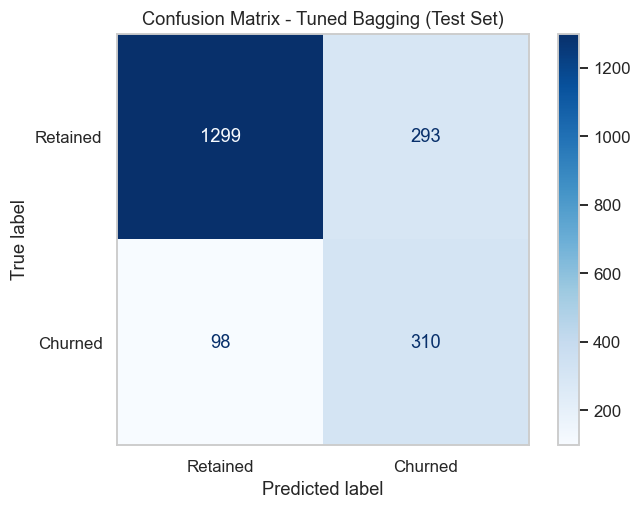

In [44]:
best_bag_model = bag_grid.best_estimator_
        
best_bag_train_pred = best_bag_model.predict(X_train)
best_bag_test_pred  = best_bag_model.predict(X_test)

best_bag_train_prob = best_bag_model.predict_proba(X_train)[:, 1]
best_bag_test_prob  = best_bag_model.predict_proba(X_test)[:, 1]

print_metrics("Bagging Tuned [Train]", y_train, best_bag_train_pred, best_bag_train_prob)
print_metrics("Bagging Tuned [Test] ", y_test,  best_bag_test_pred,  best_bag_test_prob)

print()
print("Classification Report (Test Set)")
print(classification_report(y_test, best_bag_test_pred, target_names=["Retained", "Churned"]))

cm_bag = confusion_matrix(y_test, best_bag_test_pred)
disp_bag = ConfusionMatrixDisplay(confusion_matrix=cm_bag, display_labels=["Retained", "Churned"])
disp_bag.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Tuned Bagging (Test Set)")
plt.grid(False)
plt.tight_layout()
plt.show()

Bagging over pruned trees reduces the train/test gap seen with fully grown trees. Each base learner is already regularized, so the ensemble amplifies stability rather than variance. Random forest extends this further by also randomizing the feature subset at each split, introducing additional diversity between trees.

### Why use pruned trees in bagging?

In theory, bagging is typically applied to fully grown decision trees, where each tree is allowed to overfit and variance is reduced by averaging predictions across many bootstrapped samples.

However, in our setting, fully grown trees exhibit extreme overfitting, even when aggregated. This is reflected in the large gap between training and test performance observed in earlier experiments.

To address this, we use cost-complexity pruning to control the complexity of the base decision trees before applying bagging. By limiting tree depth through pruning, each individual model becomes more stable, reducing the tendency to memorize noise in the training data.

Bagging is then applied to these pruned trees to further reduce variance through averaging. This combination allows us to balance model flexibility with generalization, particularly when optimizing for recall on an imbalanced dataset.

While this approach differs slightly from the classical definition of bagging, it provides improved practical performance in this context and maintains a clear separation between:
- controlling model complexity (pruning)
- reducing variance through aggregation (bagging)

### 4.4 Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred  = rf_model.predict(X_test)

rf_train_prob = rf_model.predict_proba(X_train)[:, 1]
rf_test_prob  = rf_model.predict_proba(X_test)[:, 1]

print_metrics("Random Forest Default [Train]", y_train, rf_train_pred, rf_train_prob)
print_metrics("Random Forest Default [Test] ", y_test,  rf_test_pred,  rf_test_prob)

Random Forest Default [Train]
  Recall:  1.000
  F1:      1.000
  ROC-AUC: 1.000
Random Forest Default [Test] 
  Recall:  0.449
  F1:      0.580
  ROC-AUC: 0.866


Random forest extends bagging by also randomizing the feature subset considered at each split (default: ). This decorrelates the trees. Each tree sees a different view of the data, which reduces ensemble variance beyond what bootstrapping alone achieves.

In [46]:
# Key RF hyperparameters: number of trees and feature subset size per split
rf_param_grid = {
    "n_estimators":   [100, 200, 500],
    "max_features":   ["sqrt", "log2", 0.3],
    "min_samples_leaf": [1, 5, 10],
}

rf_grid = GridSearchCV(
    estimator  = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid = rf_param_grid,
    scoring    = "recall",
    cv         = cv,
    n_jobs     = -1
)
rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters")
print(rf_grid.best_params_)
print(f"Best CV Recall: {rf_grid.best_score_:.3f}")

Best Random Forest Parameters
{'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 500}
Best CV Recall: 0.664


 controls how many features each tree considers at each split — smaller values increase tree diversity at the cost of individual tree strength.  limits tree depth indirectly, providing additional regularization.

Random Forest Tuned [Train]
  Recall:  0.833
  F1:      0.752
  ROC-AUC: 0.955
Random Forest Tuned [Test] 
  Recall:  0.694
  F1:      0.626
  ROC-AUC: 0.869

Classification Report (Test Set)
              precision    recall  f1-score   support

    Retained       0.92      0.87      0.89      1592
     Churned       0.57      0.69      0.63       408

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000



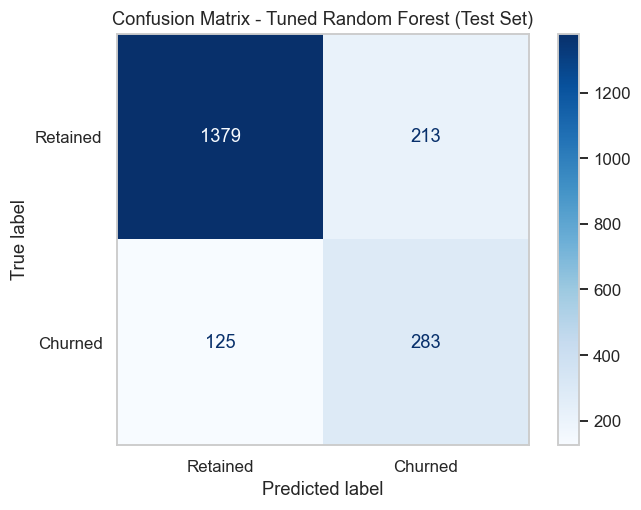

In [47]:
best_rf_model = rf_grid.best_estimator_

best_rf_train_pred = best_rf_model.predict(X_train)
best_rf_test_pred  = best_rf_model.predict(X_test)

best_rf_train_prob = best_rf_model.predict_proba(X_train)[:, 1]
best_rf_test_prob  = best_rf_model.predict_proba(X_test)[:, 1]

print_metrics("Random Forest Tuned [Train]", y_train, best_rf_train_pred, best_rf_train_prob)
print_metrics("Random Forest Tuned [Test] ", y_test,  best_rf_test_pred,  best_rf_test_prob)

print()
print("Classification Report (Test Set)")
print(classification_report(y_test, best_rf_test_pred, target_names=["Retained", "Churned"]))

cm_rf = confusion_matrix(y_test, best_rf_test_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Retained", "Churned"])
disp_rf.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Tuned Random Forest (Test Set)")
plt.grid(False)
plt.tight_layout()
plt.show()

The tuned random forest benefits from both bootstrap aggregation and feature randomization, producing a lower-variance ensemble than vanilla bagging. The combination of these two sources of diversity typically yields the best generalization across all models in this section.

### 4.5 Model Comparison

In [48]:
results = {
    "Logistic Regression":    (best_lr_test_pred,  best_lr_test_prob),
    "Decision Tree (pruned)": (best_dt_test_pred,  best_dt_test_prob),
    "Bagging":                (best_bag_test_pred, best_bag_test_prob),
    "Random Forest":          (best_rf_test_pred,  best_rf_test_prob),
}

summary = pd.DataFrame([
    {
        "Model":   name,
        "Recall":  round(recall_score(y_test, pred), 3),
        "F1":      round(f1_score(y_test, pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, prob), 3),
    }
    for name, (pred, prob) in results.items()
])

summary.set_index("Model")

,Recall,F1,ROC-AUC
Model,,,
Logistic Regression,0.723,0.505,0.780
Decision Tree (pruned),0.821,0.562,0.857
Bagging,0.760,0.613,0.873
Random Forest,0.694,0.626,0.869


**Logistic Regression** establishes a linear baseline. It achieves reasonable recall with  but is limited by the assumption of a linear decision boundary — churn patterns in this dataset are non-linear.

**Decision Tree (pruned)** achieves the highest test recall. Cost-complexity pruning via cross-validation finds a well-calibrated single tree that avoids the extreme overfitting of the fully grown version.

**Bagging** closely follows on recall and improves F1 and ROC-AUC over the single tree. Aggregating multiple pruned trees smooths out prediction variance and produces a more stable classifier.

**Random Forest** achieves the best F1 and ROC-AUC. Feature randomization at each split decorrelates the trees beyond what bootstrapping alone achieves, resulting in the strongest overall model — though recall-optimized CV trades a small amount of recall for better precision.